# <font color="red"> =============plotting BOLD timeseries=============== </font>

# <font color="red">=================plot gp timeseries================

# <font color="F527E4"> ============compare groups timeseries============

In [31]:
PBS = ["/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM835603942971011M8/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362824086011084M8/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM836223979691084M1/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362224086051084M2/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362234086021084M3/positive_bold_R_Iso_left_paw_average_timeseries.txt",]

In [32]:


PFF = ["/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362334086041083M6/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM836323993941035M4/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8363224086001085M5/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM836373993921113M9/positive_bold_R_Iso_left_paw_average_timeseries.txt",
"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362324086031084M5/positive_bold_R_Iso_left_paw_average_timeseries.txt",]

In [33]:
# load the timeseries and add them to a list
PBS_ts = []
PFF_ts = []

In [34]:
import numpy as np
for ts in PBS:
    ts = np.loadtxt(ts)
    PBS_ts.append(ts)

for ts in PFF:
    ts = np.loadtxt(ts)
    PFF_ts.append(ts)

In [35]:
# get the average and SEM for each
PBS_mean = np.mean(PBS_ts, axis=0)
PFF_mean = np.mean(PFF_ts, axis=0)
PBS_SEM = np.std(PBS_ts, axis=0) / np.sqrt(len(PBS_ts))
PFF_SEM = np.std(PFF_ts, axis=0) / np.sqrt(len(PFF_ts))

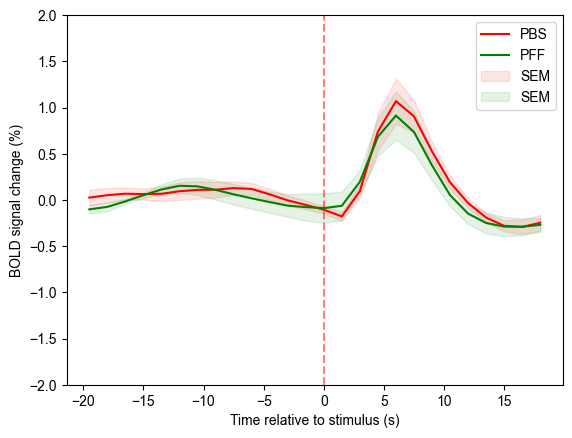

In [36]:
import matplotlib.pyplot as plt
TR = 1.5
window_size = 20  # seconds
window_points = int(window_size / TR)
time_window = np.arange(-window_points, window_points) * TR
fig, ax = plt.subplots()
ax.plot(time_window, PBS_mean, label="PBS", color="red")
ax.plot(time_window, PFF_mean, label="PFF", color="green" )

ax.fill_between(time_window, PBS_mean - PBS_SEM, PBS_mean + PBS_SEM, alpha=0.1, label="SEM", color="red")
ax.fill_between(time_window, PFF_mean - PFF_SEM, PFF_mean + PFF_SEM, alpha=0.1, label="SEM", color="green")

ax.axvline(x=0, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("Time relative to stimulus (s)")
ax.set_ylabel("BOLD signal change (%)")

ax.set_ylim(-2, 2)
ax.legend()

# <font color="F527E4"> ============compare groups all activation timeseries============

In [37]:
import numpy as np
import matplotlib.pyplot as plt
# Set the font to Arial
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['svg.fonttype'] = 'none'
from scipy.ndimage import gaussian_filter1d

In [38]:
TR = 1.5
window_size = 20  # seconds
window_points = int(window_size / TR)
time_window = np.arange(-window_points, window_points) * TR

In [39]:
activations = [        'negative_bold_L_ENTI_left_paw_average_timeseries.txt',
        'positive_bold_L_Striatum_left_paw_average_timeseries.txt',
        'positive_bold_R_Iso_left_paw_average_timeseries.txt',
        'positive_bold_L_Iso_left_paw_average_timeseries.txt'
               ]


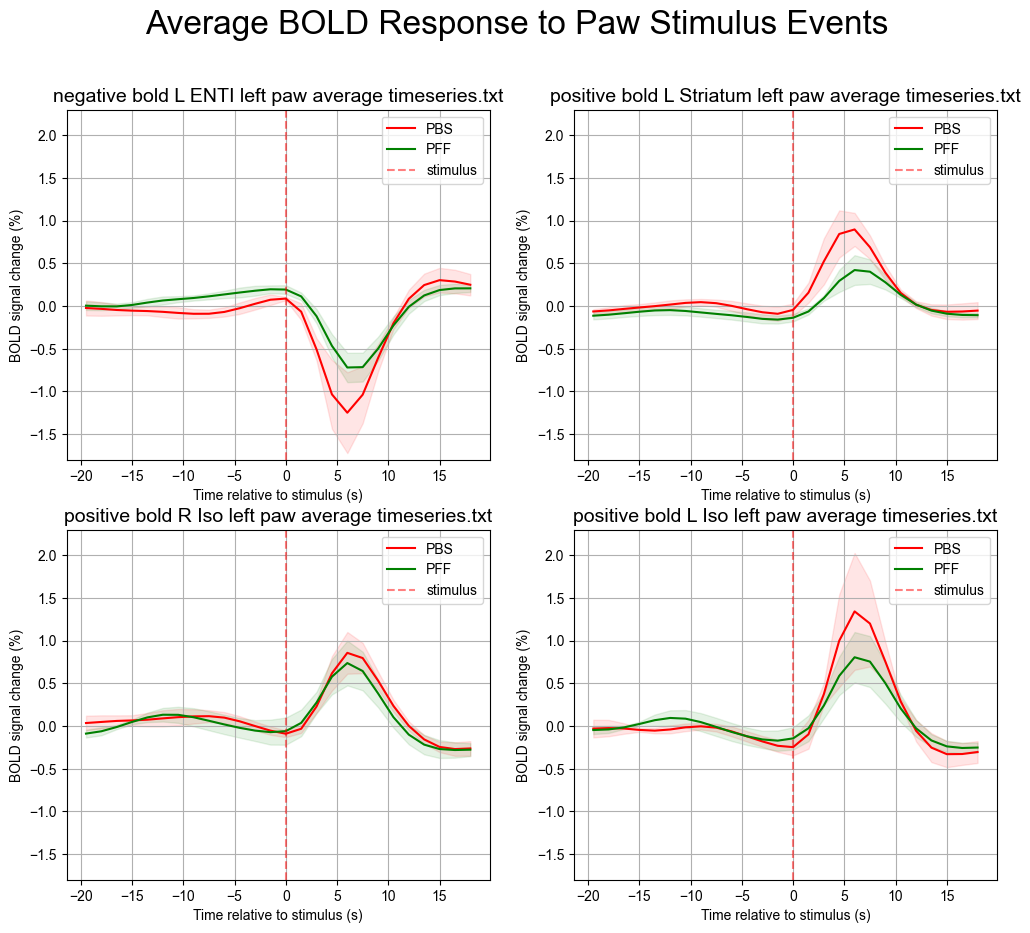

In [53]:
fig, axes = plt.subplots(2,2, figsize = (12,10))
axes = axes.flatten()
fig.suptitle('Average BOLD Response to Paw Stimulus Events', fontsize=24)
for activation, ax in zip(activations, axes):
    PBS = [f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM835603942971011M8/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362824086011084M8/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM836223979691084M1/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362224086051084M2/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362234086021084M3/{activation}",]


    PFF = [f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362334086041083M6/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM836323993941035M4/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8363224086001085M5/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM836373993921113M9/{activation}",
    f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_regions_timeseries_OutputDir/average_timeseries/_run-1_ses-01_sub-hM8362324086031084M5/{activation}",]

    # load the timeseries and add them to a list
    PBS_ts = []
    PFF_ts = []

    for ts in PBS:
        ts = np.loadtxt(ts)
        PBS_ts.append(ts)

    for ts in PFF:
        ts = np.loadtxt(ts)
        PFF_ts.append(ts)
    # get the average and SEM for each
    PBS_mean = np.mean(PBS_ts, axis=0)
    PFF_mean = np.mean(PFF_ts, axis=0)
    PBS_SEM = np.std(PBS_ts, axis=0) / np.sqrt(len(PBS))
    PFF_SEM = np.std(PFF_ts, axis=0) / np.sqrt(len(PFF))

    PBS_mean_smooth = gaussian_filter1d(PBS_mean, sigma=1)
    PFF_mean_smooth = gaussian_filter1d(PFF_mean, sigma=1)

    ax.plot(time_window, PBS_mean_smooth, label="PBS", color="red")
    ax.plot(time_window, PFF_mean_smooth, label="PFF", color="green")

    # ax.plot(time_window, PBS_mean, label="PBS", color="red")
    # ax.plot(time_window, PFF_mean, label="PFF", color="green" )
    # remove underscores from activation name
    activation_title = activation.replace("_"," ")
    ax.set_title(f"{activation_title}", fontsize=14)

    ax.fill_between(time_window, PBS_mean_smooth - PBS_SEM, PBS_mean_smooth + PBS_SEM, alpha=0.1, color="red")
    ax.fill_between(time_window, PFF_mean_smooth - PFF_SEM, PFF_mean_smooth + PFF_SEM, alpha=0.1, color="green")

    # ax.fill_between(time_window, PBS_mean - PBS_SEM, PBS_mean + PBS_SEM, alpha=0.1, label="SEM", color="red")
    # ax.fill_between(time_window, PFF_mean - PFF_SEM, PFF_mean + PFF_SEM, alpha=0.1, label="SEM", color="green")

    ax.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="stimulus")
    # ax.axhline(y=0, color="red", linestyle="-", alpha=0.5, )
    ax.set_xlabel("Time relative to stimulus (s)")
    ax.set_ylabel("BOLD signal change (%)")

    ax.set_ylim(-1.8, 2.3)
    # remove grid
    ax.grid()
    ax.legend()

plt.savefig("/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/figures/Motor_cortex_activation/avg_BOLD_activation.svg")



In [41]:
for activation, ax in zip(activations, axes):
    print(activation)
    print(ax)


negative_bold_L_ENTI_left_paw_average_timeseries.txt
Axes(0.125,0.53;0.352273x0.35)
positive_bold_L_Striatum_left_paw_average_timeseries.txt
Axes(0.547727,0.53;0.352273x0.35)
positive_bold_R_Iso_left_paw_average_timeseries.txt
Axes(0.125,0.11;0.352273x0.35)
positive_bold_L_Iso_left_paw_average_timeseries.txt
Axes(0.547727,0.11;0.352273x0.35)


In [42]:
PBS_mean = np.mean(PBS_ts, axis=0)

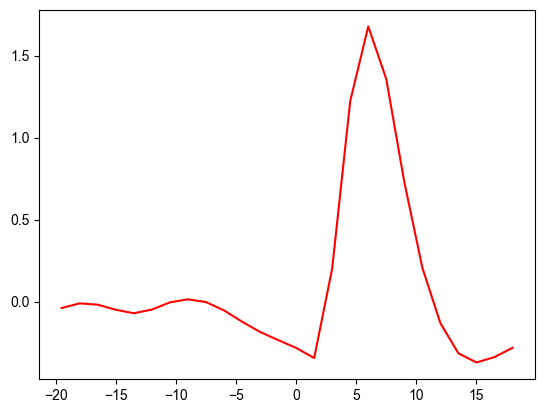

In [43]:
plt.plot(time_window, PBS_mean, label="PBS", color="red")

In [44]:
len(PBS)

5

# <font color="#DE3D12"> ==================plot all copes for each subject=============

In [45]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [46]:
copes_outputdir = "/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/2nd_level_copes_images"
if not os.path.exists(copes_outputdir):
    os.makedirs(copes_outputdir)

In [47]:
subjects_names_PBS = ['hM835603942971011M8',
'hM8362824086011084M8',
'hM836223979691084M1',
'hM8362224086051084M2',
'hM8362234086021084M3',]

subjects_names_PFF = ['hM8362334086041083M6',
'hM836323993941035M4',
'hM8363224086001085M5',
'hM836373993921113M9',
'hM8362324086031084M5',]

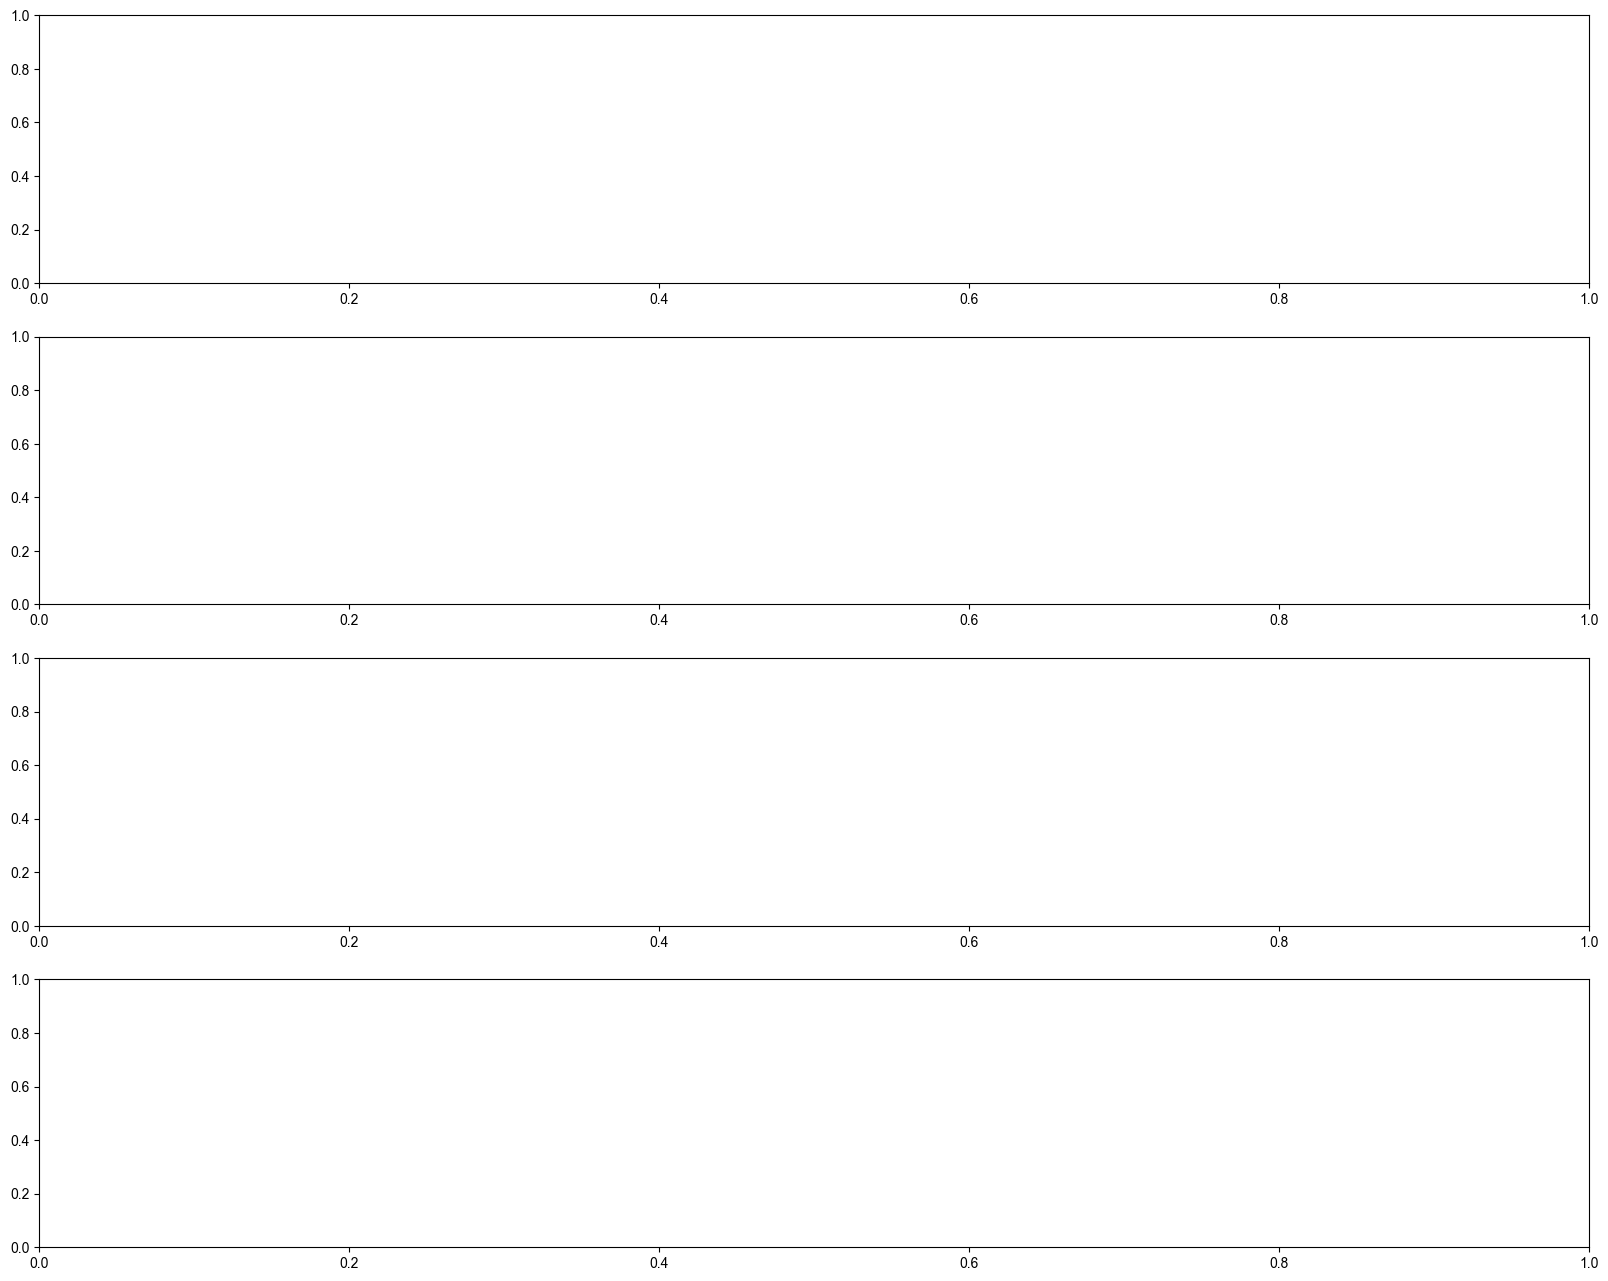

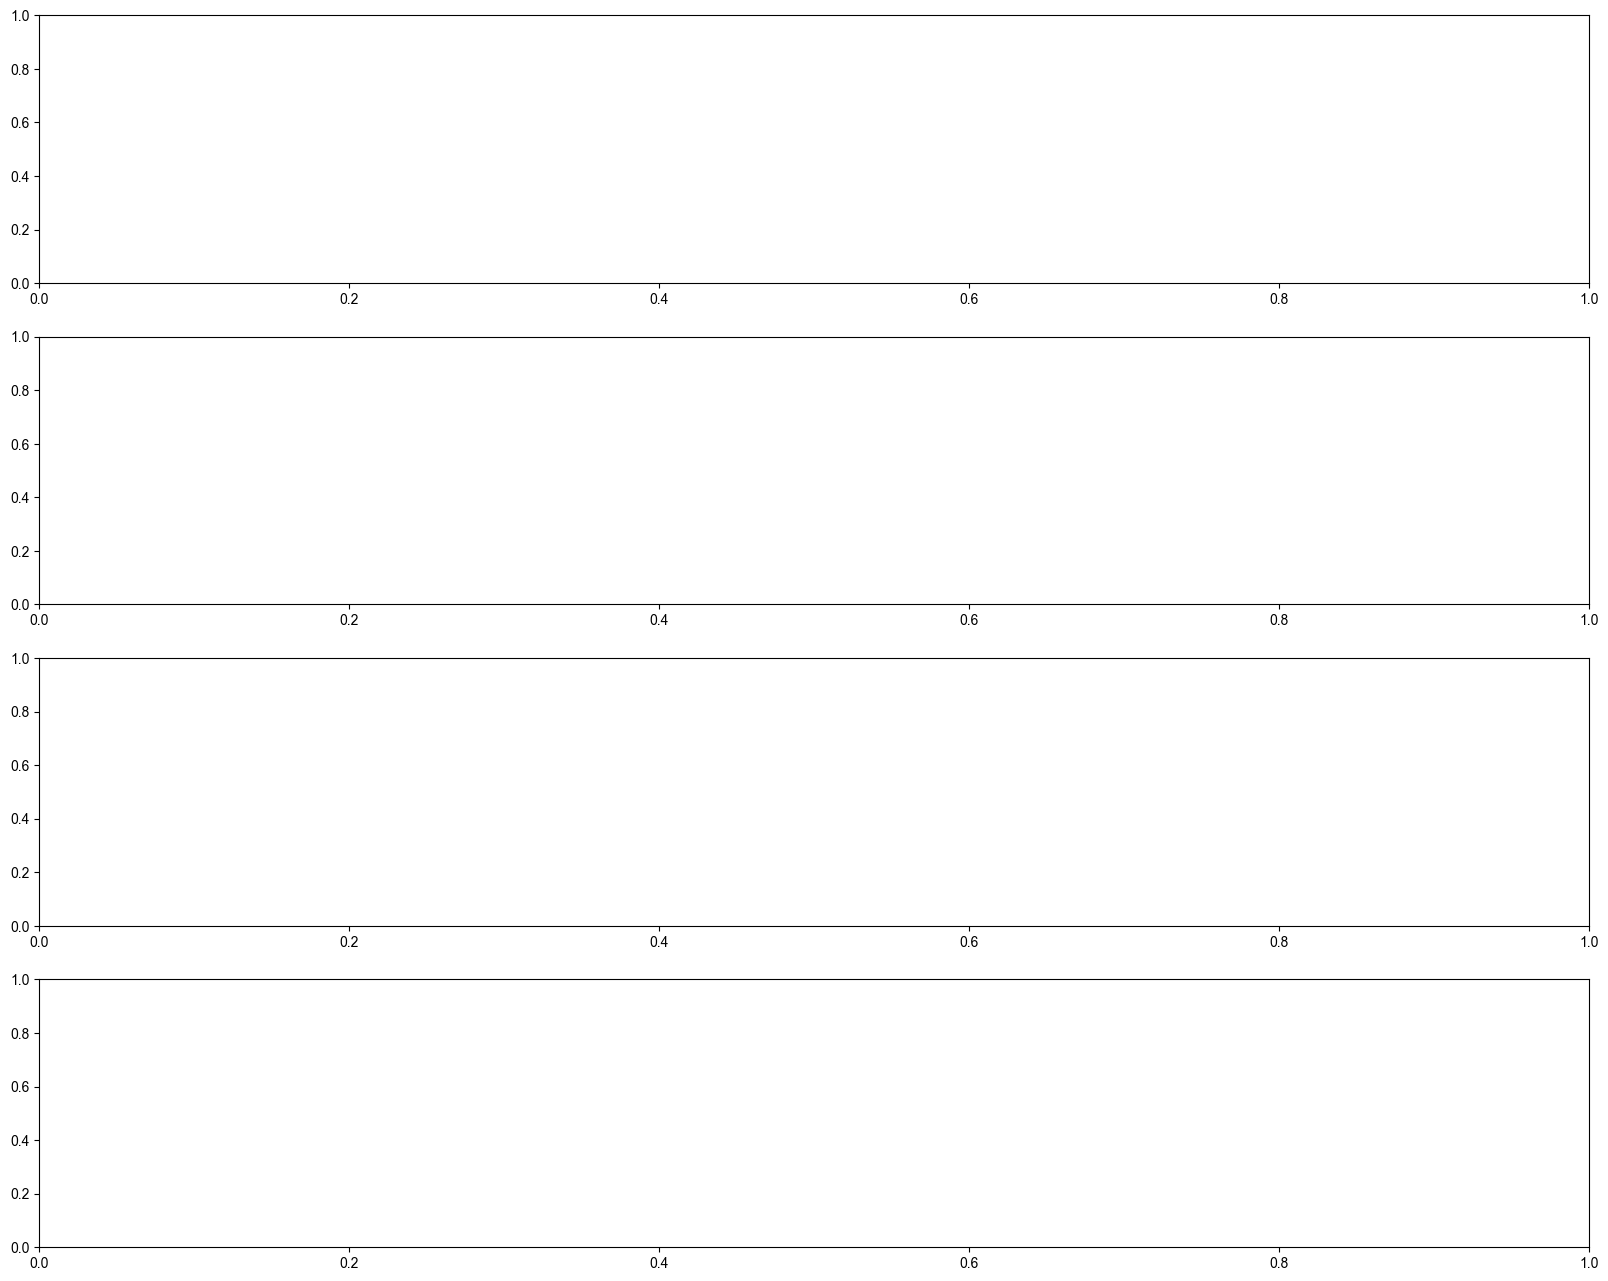

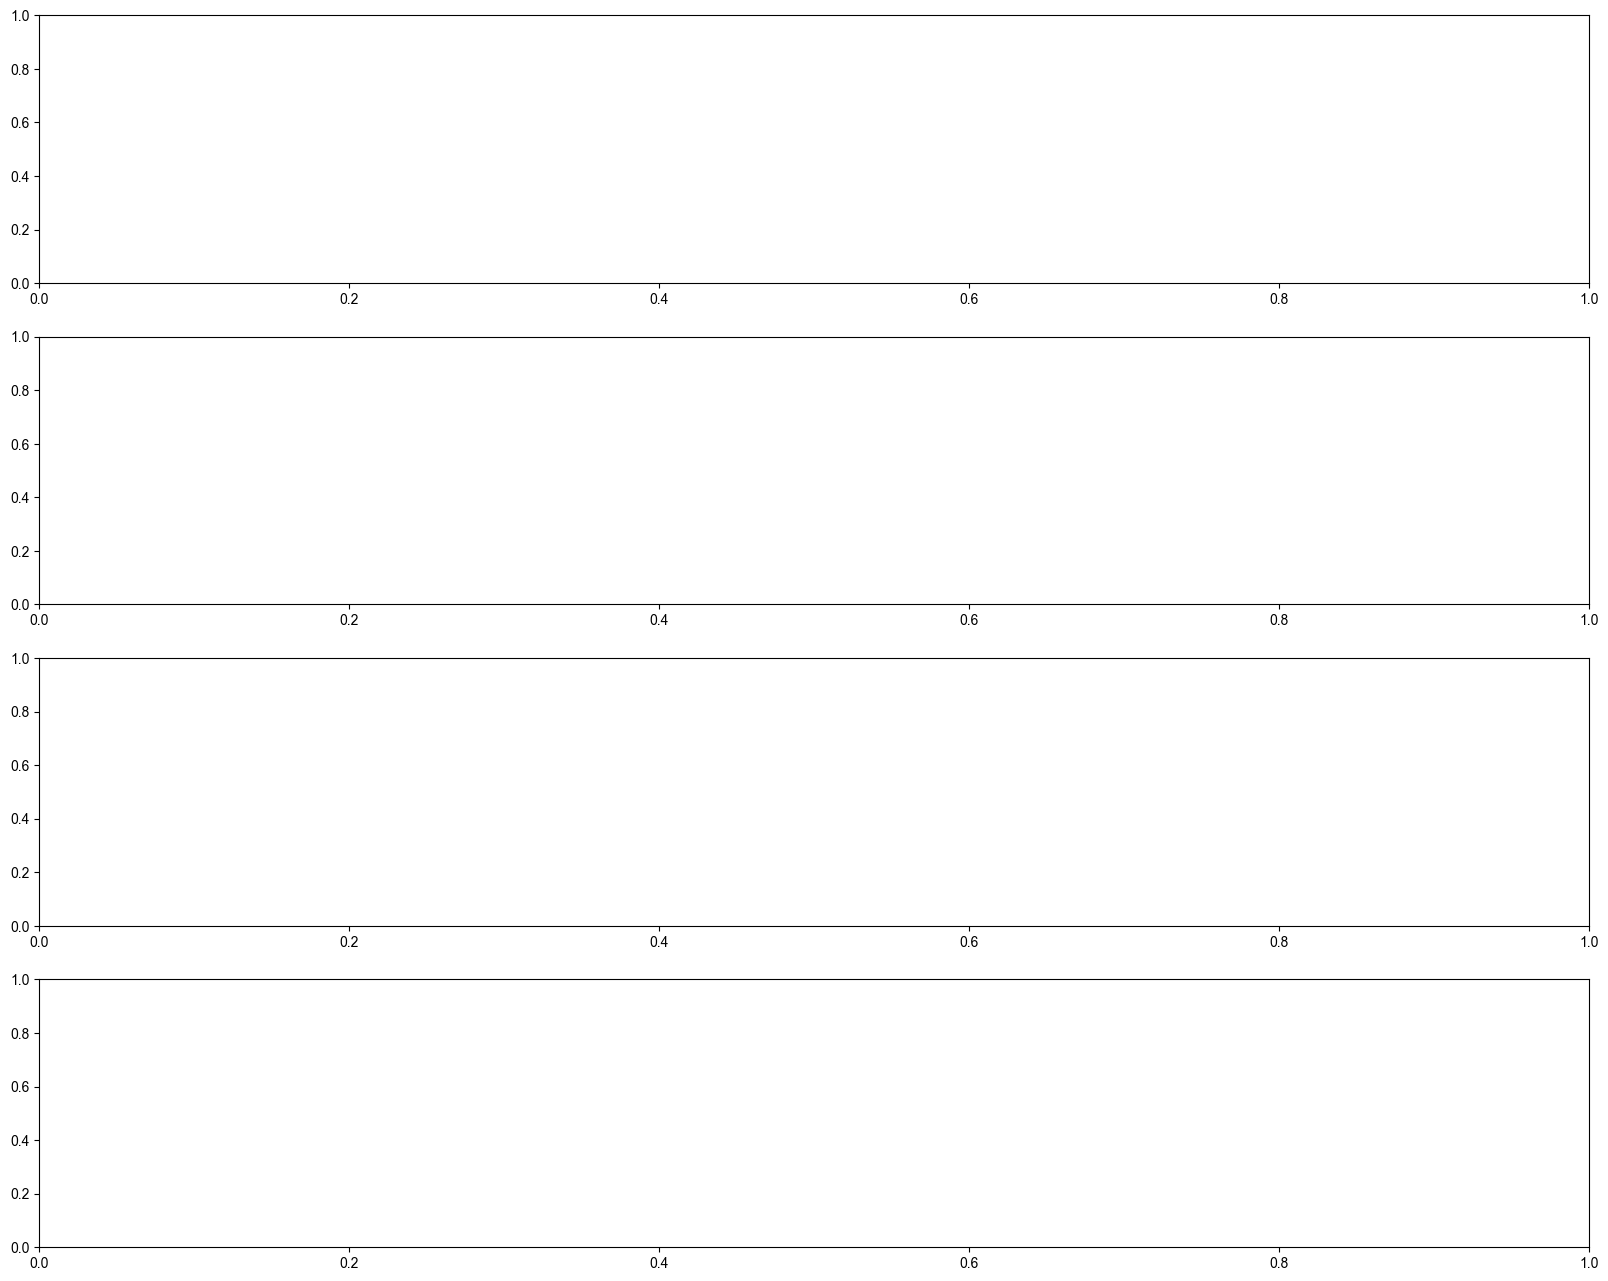

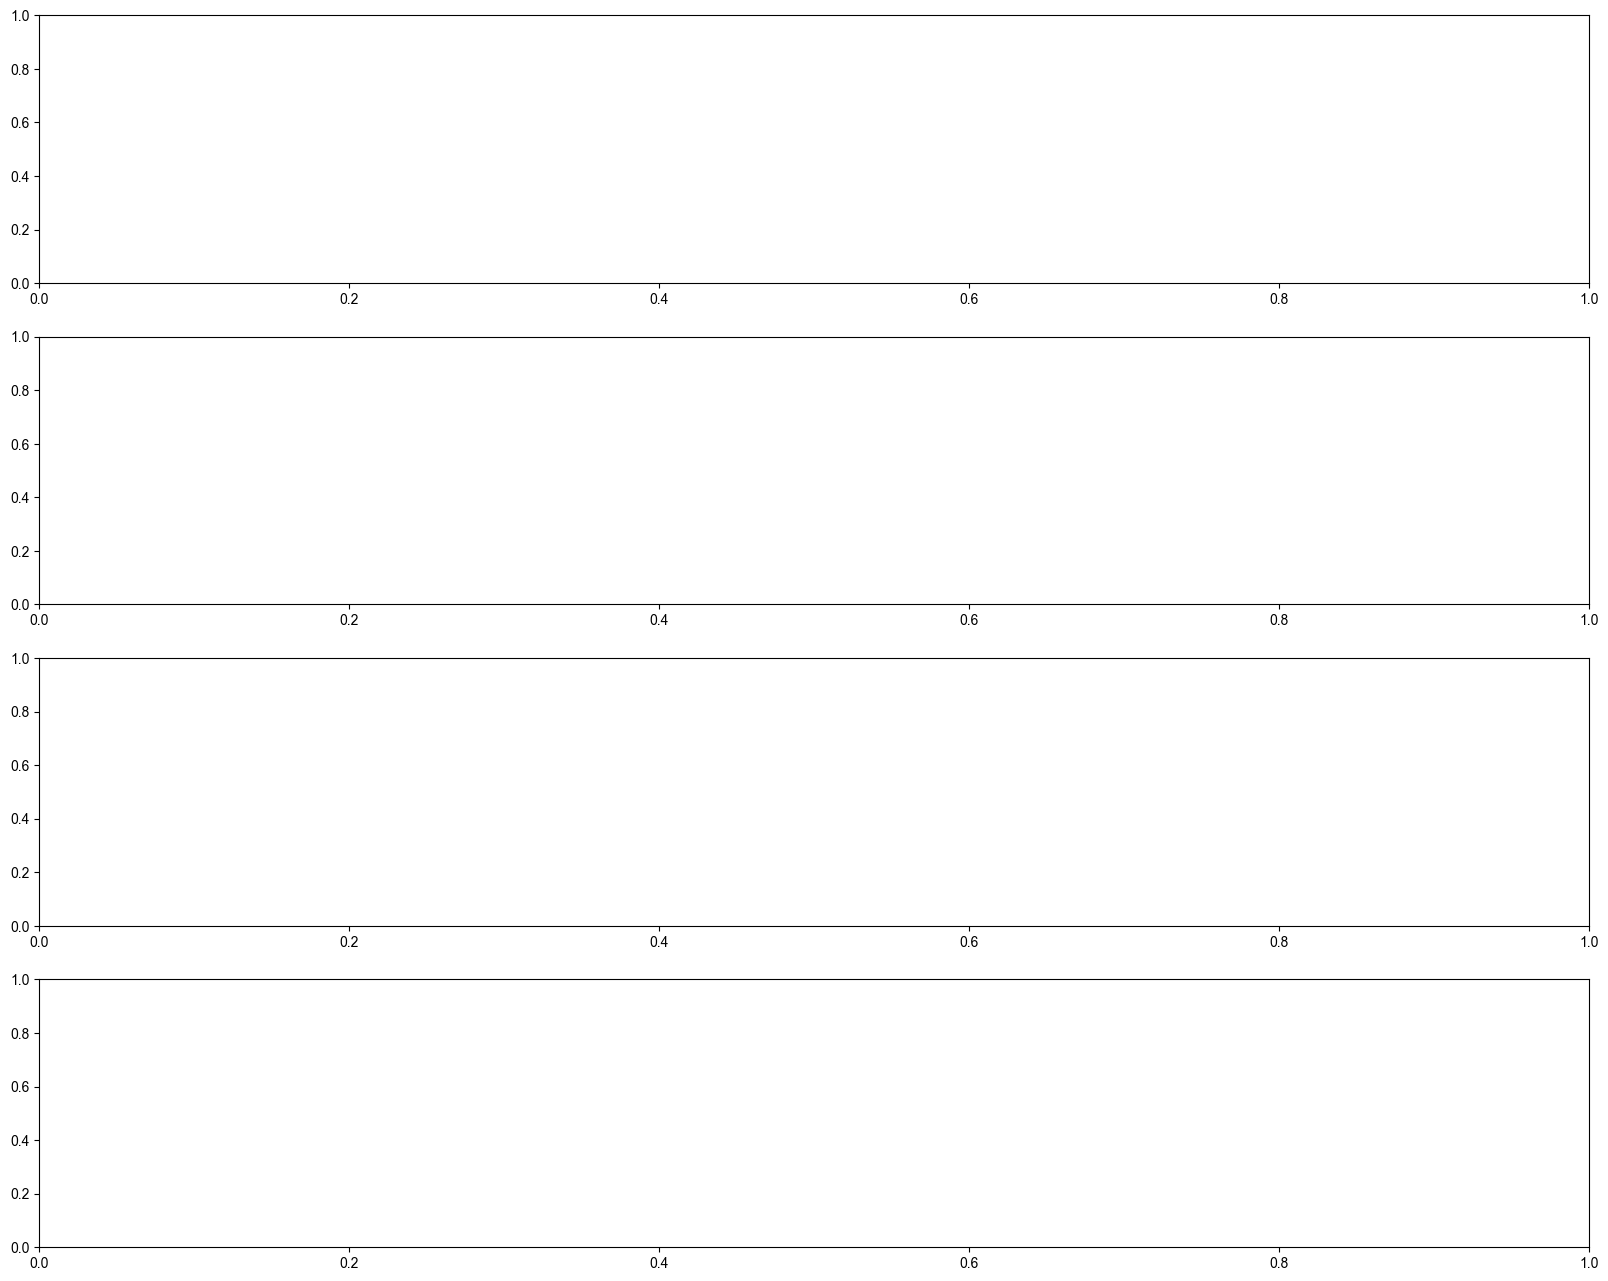

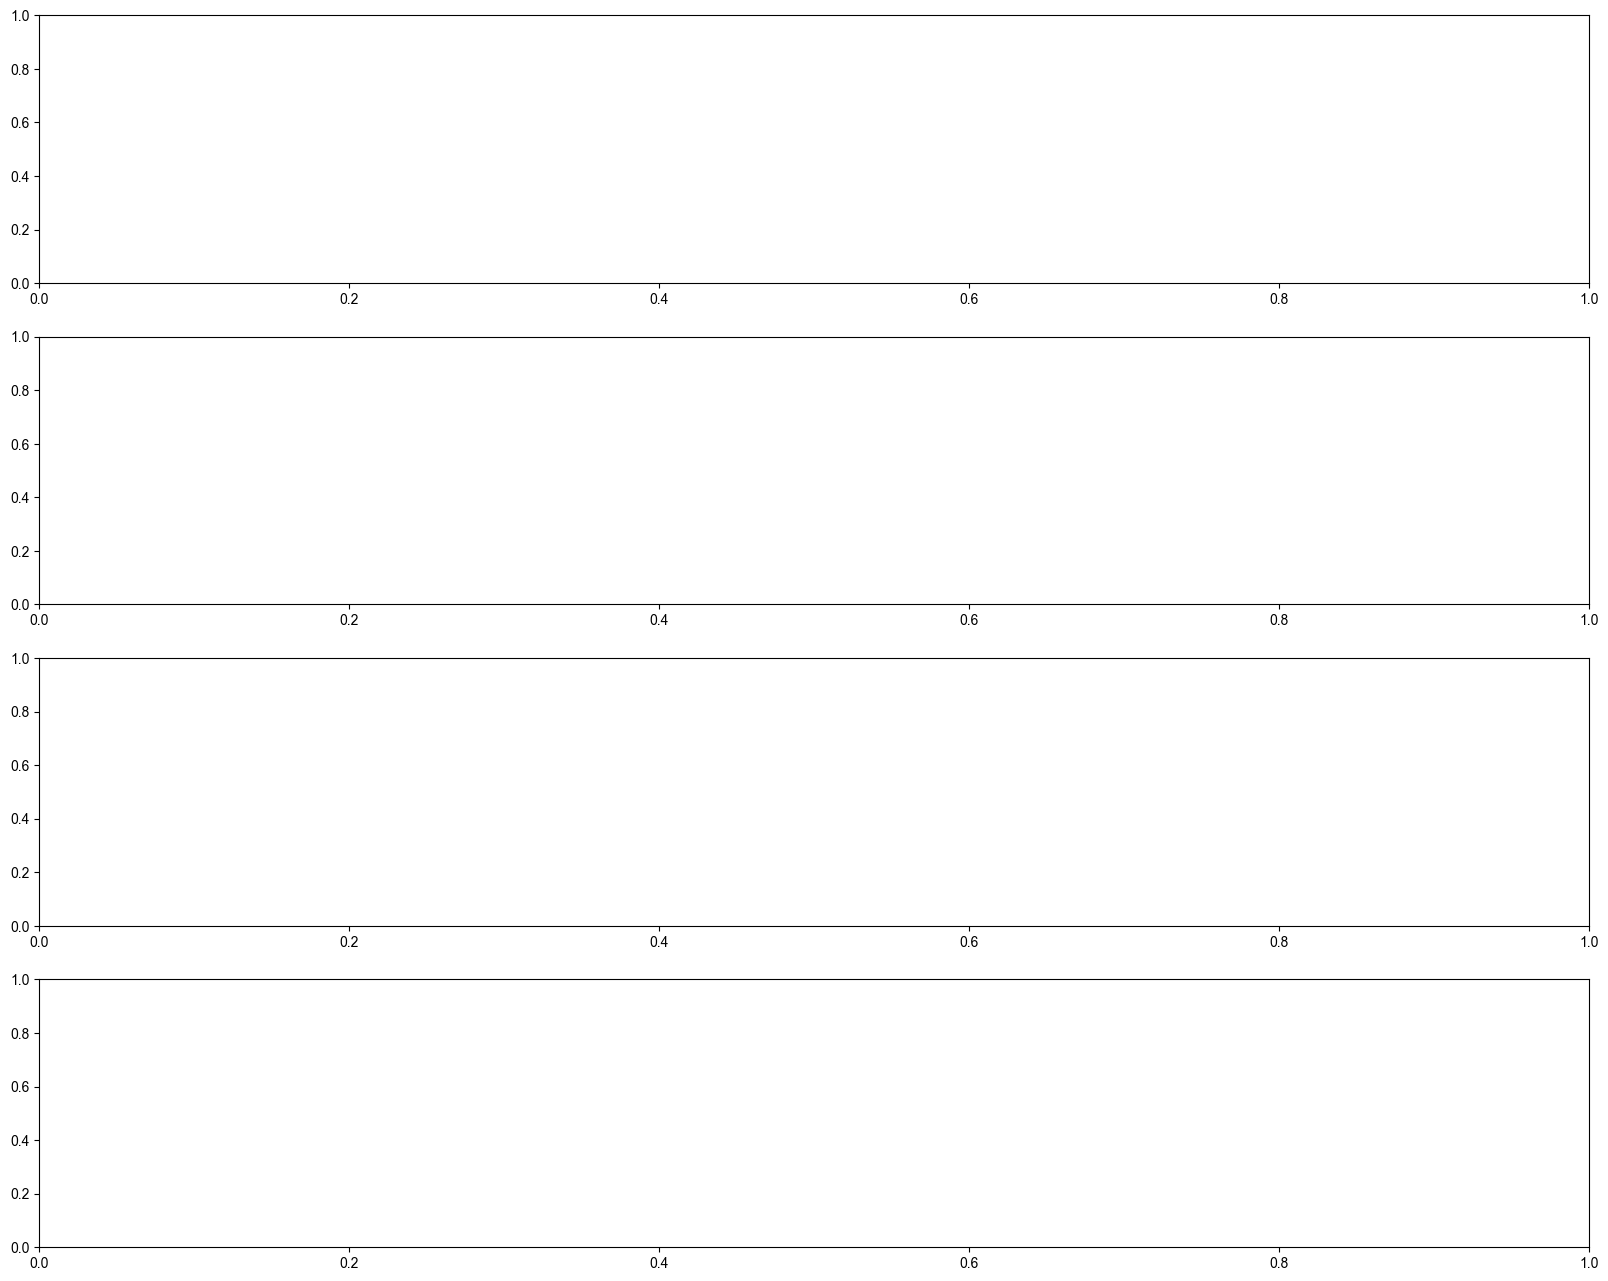

In [48]:
for subject in subjects_names_PBS:
    copes_list = glob.glob(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_OutputDir/cope_activation_pic/cope?_ses-01_{subject}/cope?_ses_01_{subject}_thresh_zstat.png")
    # sort the list alphabtically
    copes_list.sort()

    fig, axes = plt.subplots(4, figsize=(20, 16))
    axes = axes.flatten()
    for ax, cope in zip(axes, copes_list):
        name = os.path.basename(cope)
        img = Image.open(cope)
        ax.imshow(img)
        ax.axis('off')

        plt.savefig(f"{copes_outputdir}/{subject}_PBS.png")



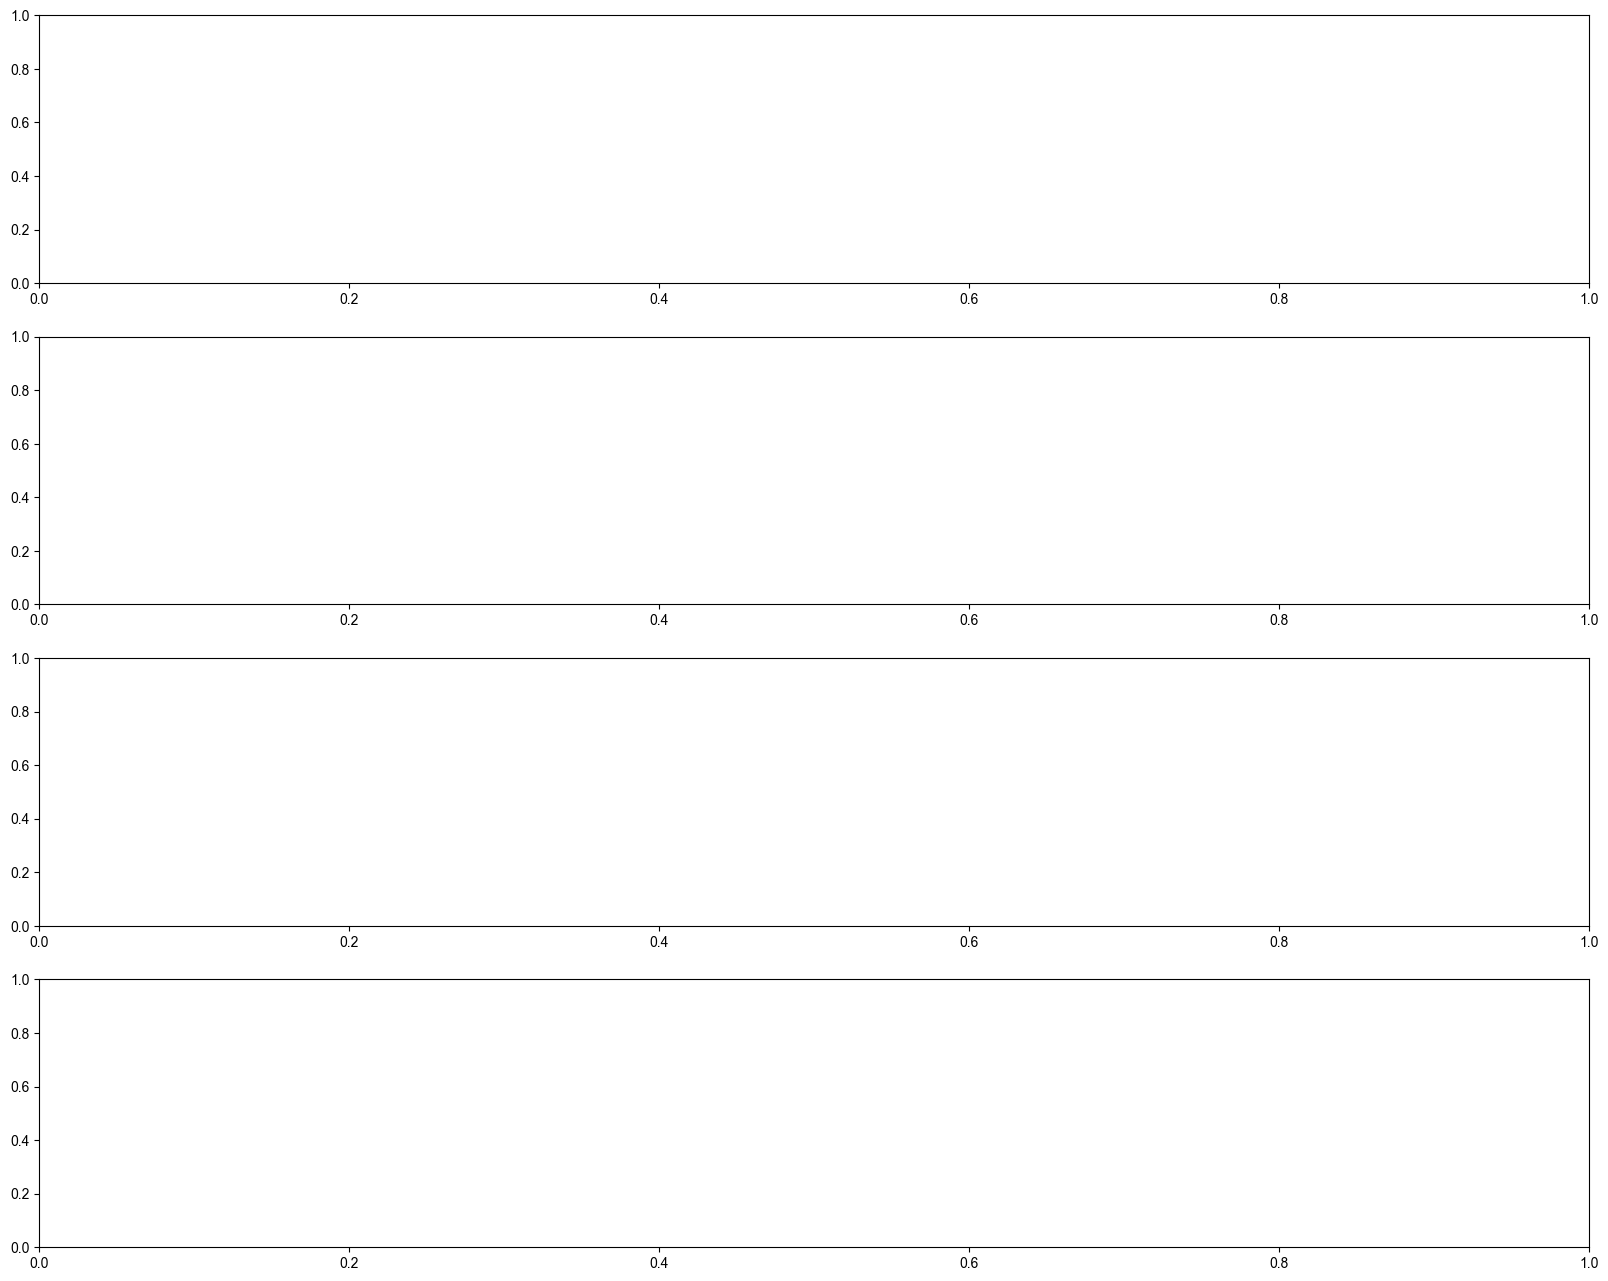

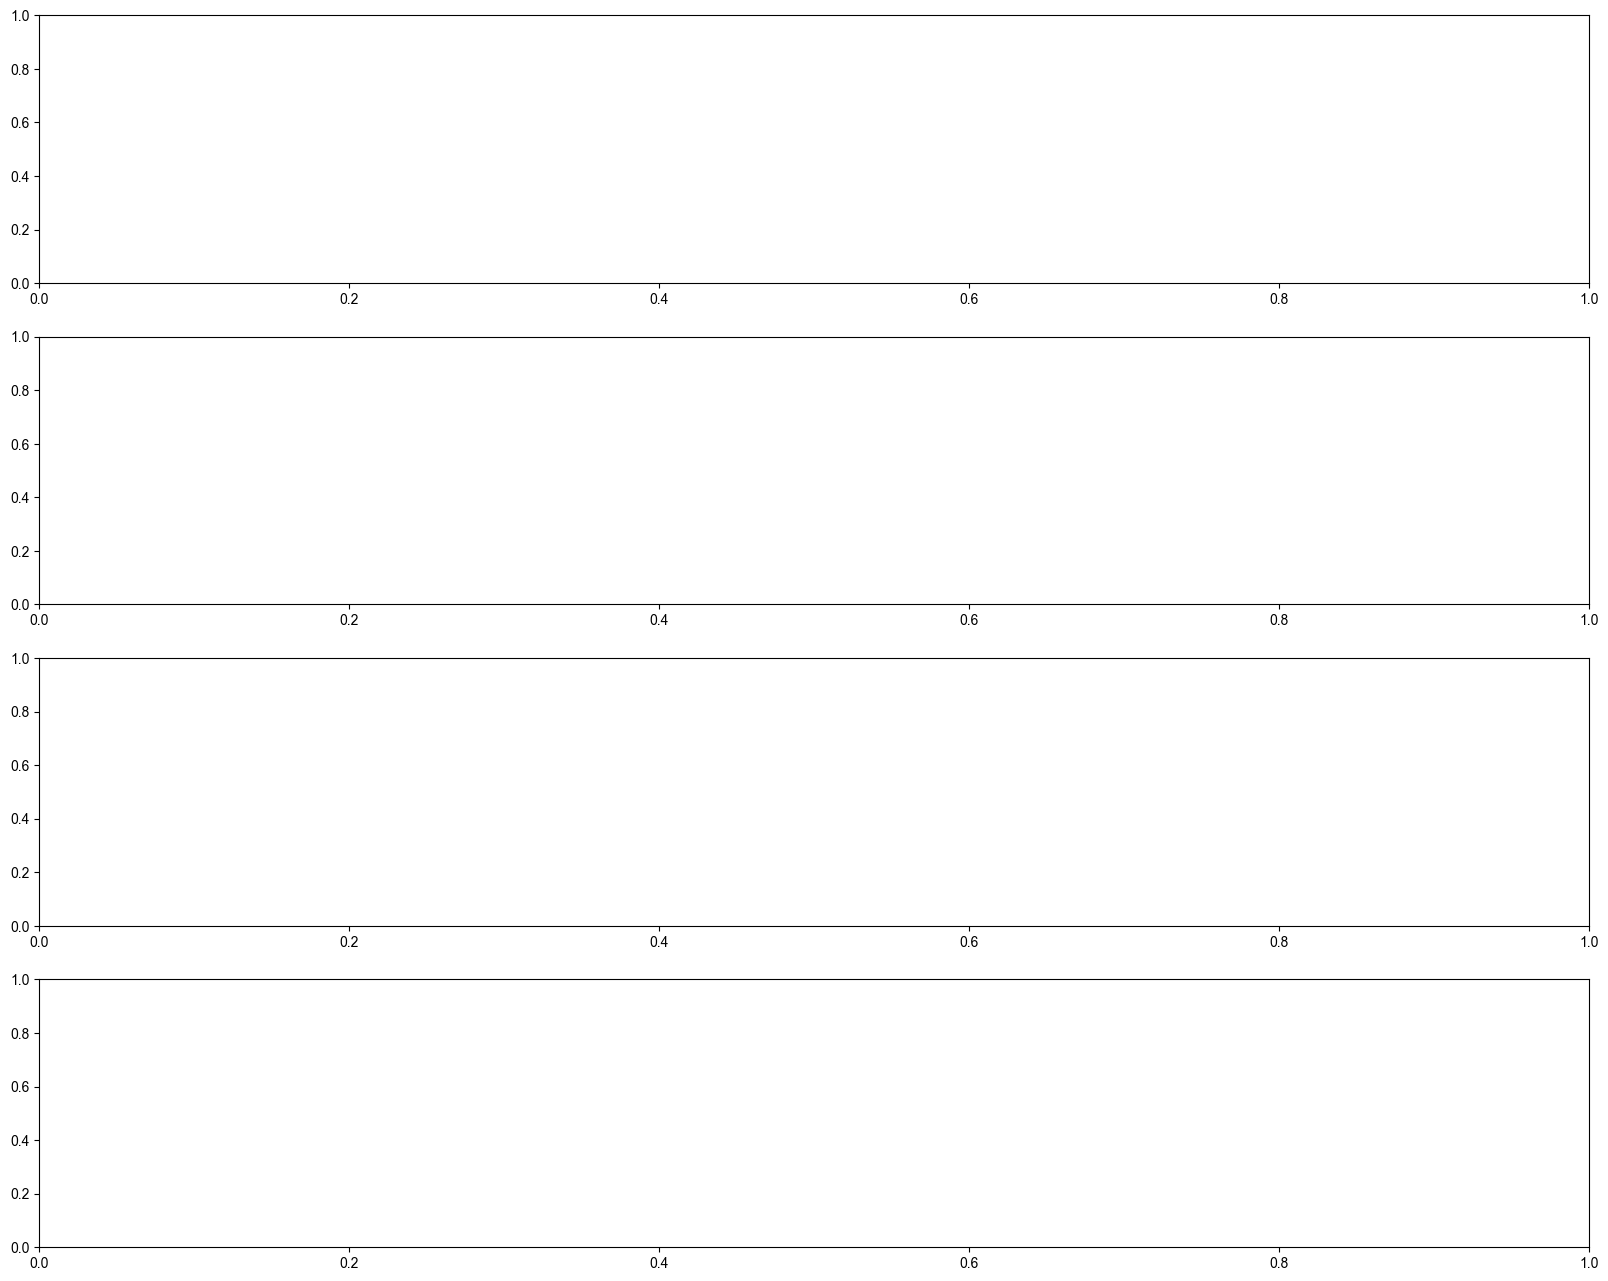

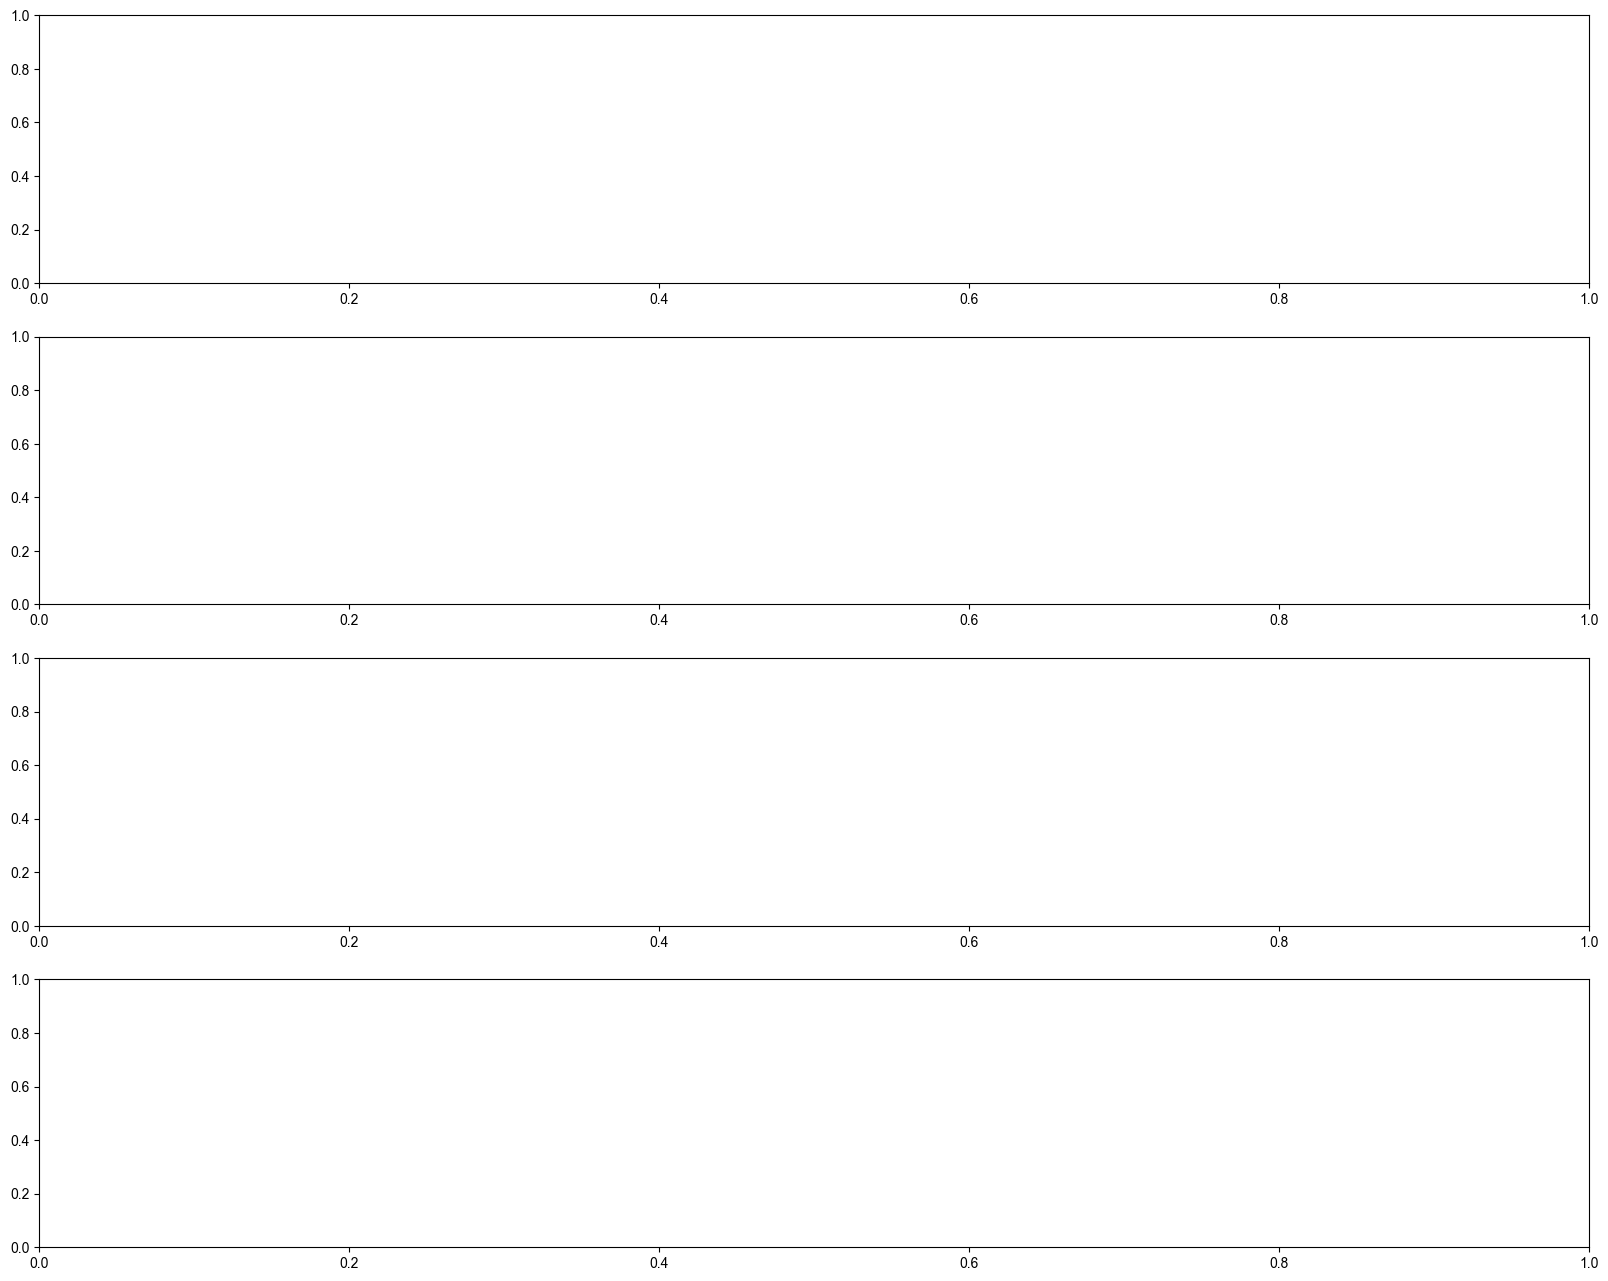

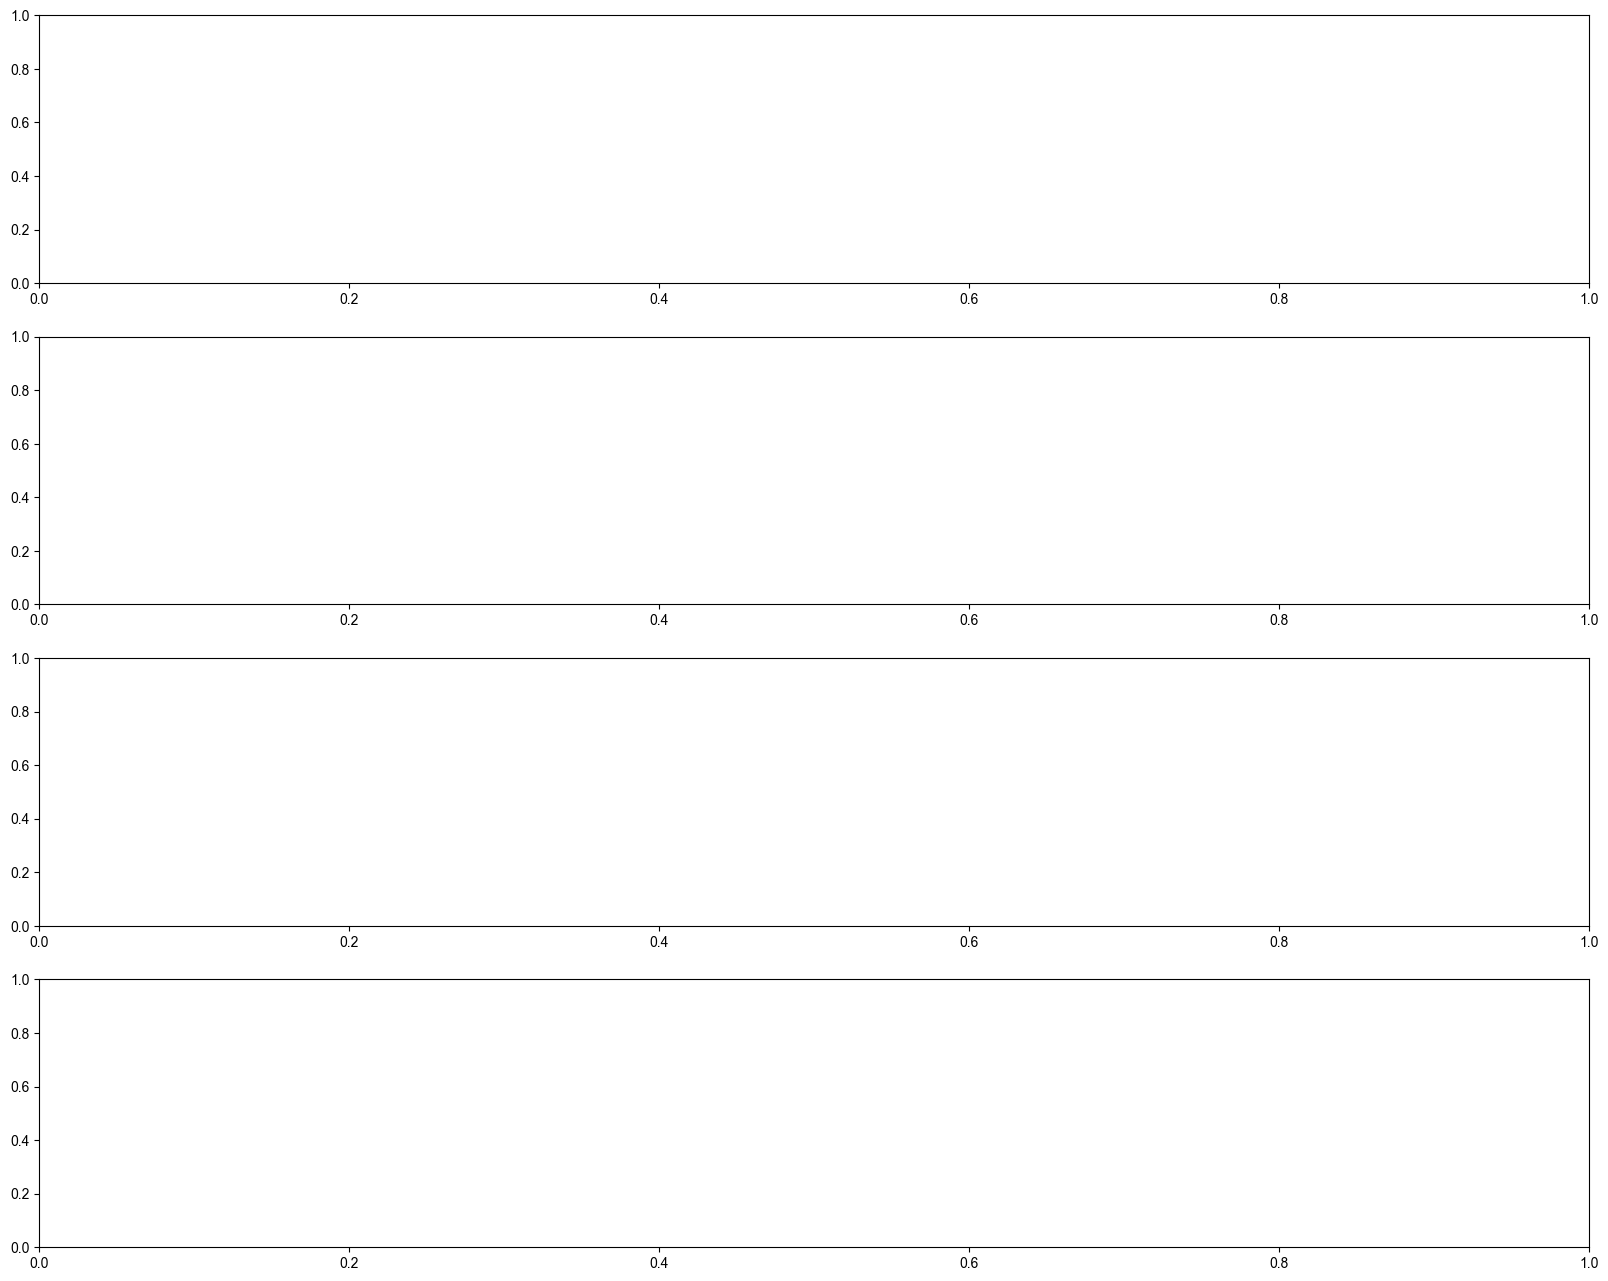

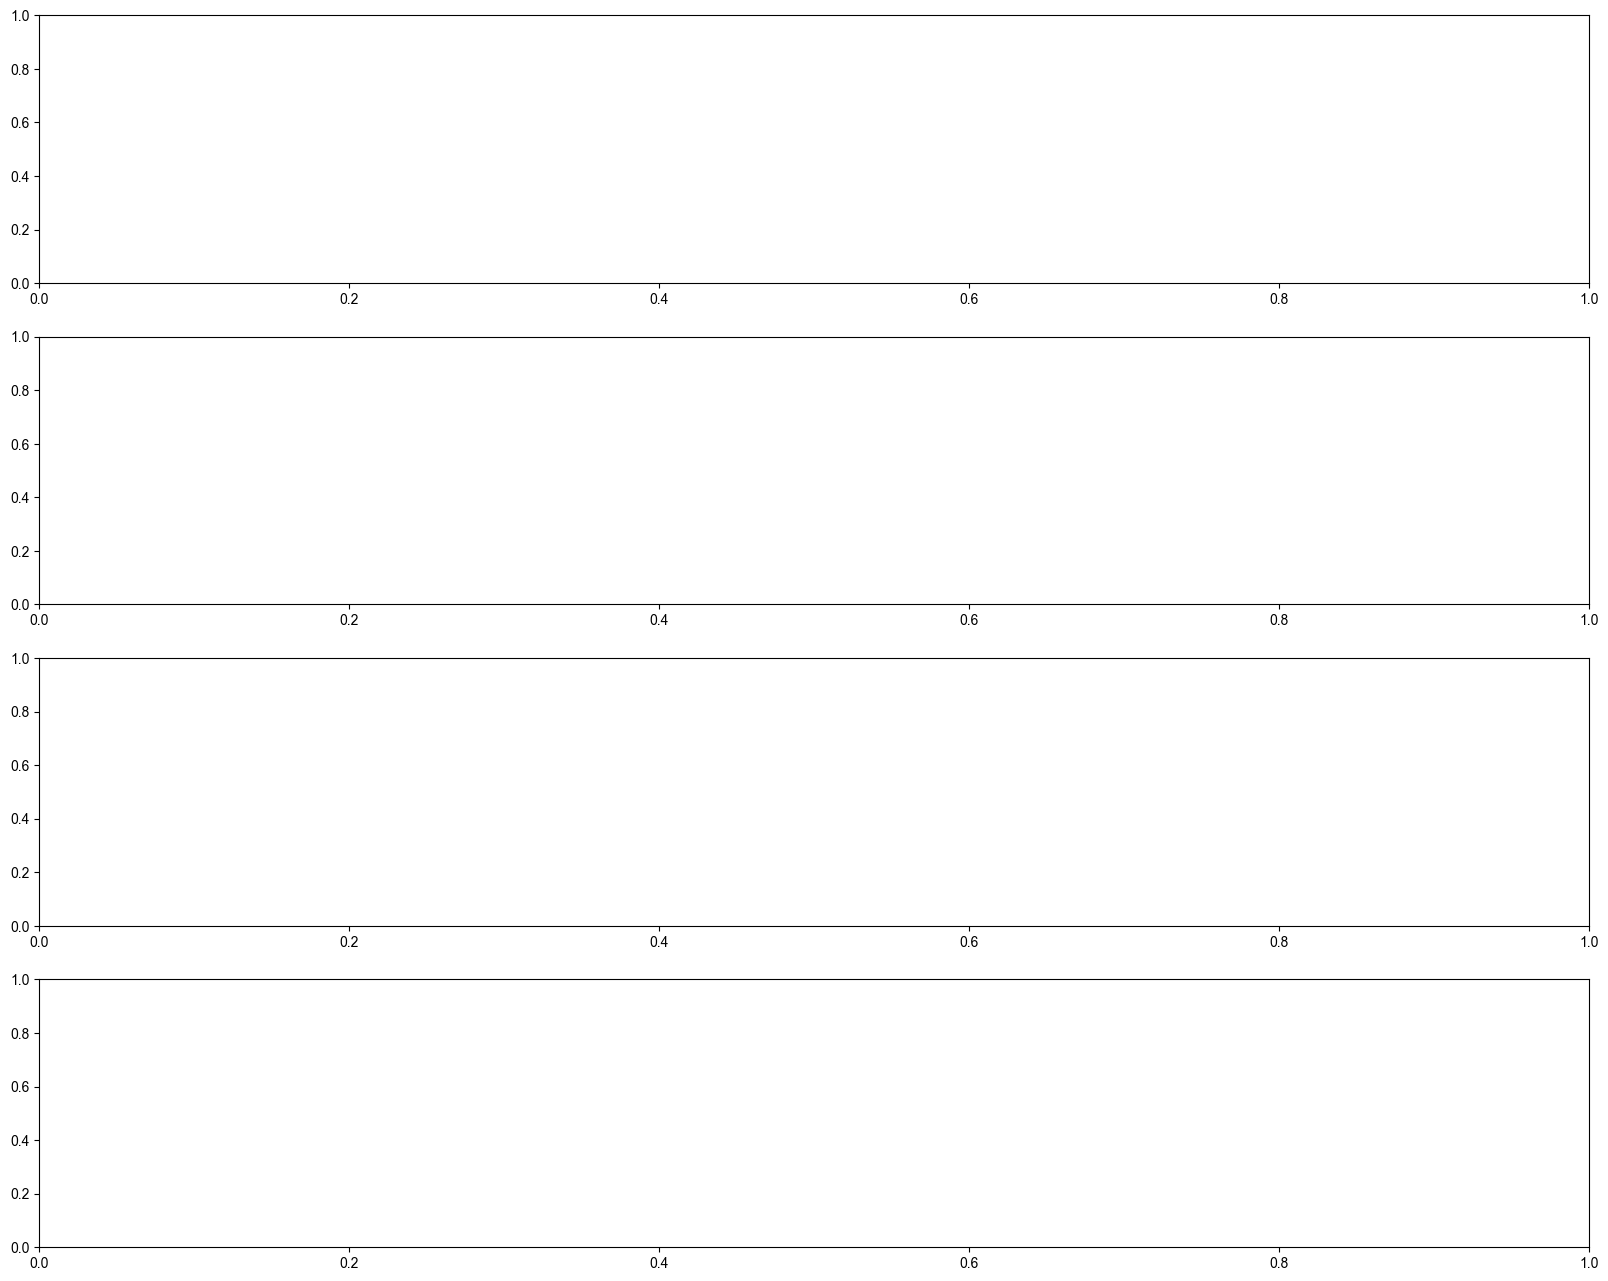

In [49]:
for subject in subjects_names_PFF:
    copes_list = glob.glob(f"/Users/aeed/Documents/Work/M83_clearing/Manuscript_analysis/Motor_cortex_dgamma_5_smooth_just_motion/Motor_cortex_activation_2nd_level_OutputDir/cope_activation_pic/cope?_ses-01_{subject}/cope?_ses_01_{subject}_thresh_zstat.png")
    # sort the list alphabtically
    copes_list.sort()

    fig, axes = plt.subplots(4, figsize=(20, 16))
    axes = axes.flatten()
    for ax, cope in zip(axes, copes_list):
        name = os.path.basename(cope)
        img = Image.open(cope)
        ax.imshow(img)
        ax.axis('off')

        plt.savefig(f"{copes_outputdir}/{subject}_PFF.png")

